In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix, classification_report
)

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")


In [4]:
# 1. Загрузка данных

FILE_PATH = "Данные_для_курсовои_Классическое_МО.xlsx"
ID_COL = "Unnamed: 0"
RANDOM_STATE = 42

df = pd.read_excel(FILE_PATH)

print("Исходная размерность:", df.shape)
display(df.head())

if ID_COL in df.columns:
    df = df.drop(columns=[ID_COL])

print("Размерность после удаления индексного столбца:", df.shape)

Исходная размерность: (1001, 214)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


Размерность после удаления индексного столбца: (1001, 213)


Медиана IC50 = 46.585183

Распределение классов:
target
0    501
1    500
Name: count, dtype: int64

Доли классов:
target
0    0.5005
1    0.4995
Name: proportion, dtype: float64


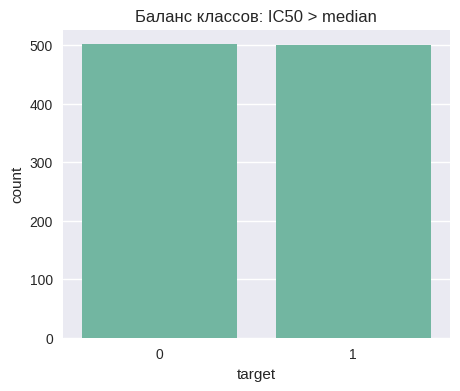

In [5]:
# 2. Подготовка целевой переменной


median_value = df["IC50, mM"].median()
df["target"] = (df["IC50, mM"] > median_value).astype(int)

X = df.drop(columns=["IC50, mM", "CC50, mM", "SI", "target"])
y = df["target"]

print(f"Медиана IC50 = {median_value:.6f}")
print("\nРаспределение классов:")
print(y.value_counts())
print("\nДоли классов:")
print(y.value_counts(normalize=True))

plt.figure(figsize=(5, 4))
sns.countplot(x=y)
plt.title("Баланс классов: IC50 > median")
plt.show()

In [6]:
# 3. Разделение на train/test


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train X:", X_train.shape)
print("Test X:", X_test.shape)
print("Train y:", y_train.shape)
print("Test y:", y_test.shape)

Train X: (800, 210)
Test X: (201, 210)
Train y: (800,)
Test y: (201,)


In [7]:
# 4. Вспомогательные функции и модели


def clf_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_proba)
    }

def build_logreg():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ])

def build_rf():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ])

def build_et():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("model", ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ])

def build_gbc():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])

models = {
    "LogisticRegression": build_logreg(),
    "RandomForest": build_rf(),
    "ExtraTrees": build_et(),
    "GradientBoosting": build_gbc()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [8]:
# 5. Базовые модели (5-fold CV)


baseline_results = []

for name, model in models.items():
    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring={
            "acc": "accuracy",
            "bal_acc": "balanced_accuracy",
            "f1": "f1",
            "roc_auc": "roc_auc"
        },
        n_jobs=-1,
        return_train_score=False
    )

    baseline_results.append({
        "Model": name,
        "CV_Accuracy": scores["test_acc"].mean(),
        "CV_Balanced_Accuracy": scores["test_bal_acc"].mean(),
        "CV_F1": scores["test_f1"].mean(),
        "CV_ROC_AUC": scores["test_roc_auc"].mean()
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("CV_ROC_AUC", ascending=False)
print("Базовые модели (5-fold CV):")
display(baseline_df)

Базовые модели (5-fold CV):


,Model,CV_Accuracy,CV_Balanced_Accuracy,CV_F1,CV_ROC_AUC
1,RandomForest,0.73375,0.73375,0.728431,0.814266
3,GradientBoosting,0.73375,0.73375,0.725094,0.799859
2,ExtraTrees,0.73625,0.73625,0.725008,0.797203
0,LogisticRegression,0.67375,0.67375,0.677419,0.739219


In [9]:
# 6. Подбор гиперпараметров


search_spaces = {
    "LogisticRegression": {
        "model__C": np.logspace(-3, 2, 50),
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"]
    },
    "RandomForest": {
        "model__n_estimators": [200, 300, 500, 700],
        "model__max_depth": [None, 5, 10, 15, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", 0.5, 0.8]
    },
    "ExtraTrees": {
        "model__n_estimators": [200, 300, 500, 700],
        "model__max_depth": [None, 5, 10, 15, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", 0.5, 0.8]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__max_depth": [2, 3, 4, 5],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__min_samples_split": [2, 5, 10]
    }
}

best_models = {}
tuning_results = []

for name, model in models.items():
    print(f"\nПодбор гиперпараметров для {name}...")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=search_spaces[name],
        n_iter=20,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_
    tuning_results.append({
        "Model": name,
        "Best_CV_ROC_AUC": search.best_score_,
        "Best_Params": search.best_params_
    })

tuning_df = pd.DataFrame(tuning_results).sort_values("Best_CV_ROC_AUC", ascending=False)
print("Результаты после тюнинга:")
display(tuning_df)


Подбор гиперпараметров для LogisticRegression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Подбор гиперпараметров для RandomForest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Подбор гиперпараметров для ExtraTrees...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Подбор гиперпараметров для GradientBoosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Результаты после тюнинга:


,Model,Best_CV_ROC_AUC,Best_Params
2,ExtraTrees,0.819969,"{'model__n_estimators': 300, 'model__min_sampl..."
1,RandomForest,0.819562,"{'model__n_estimators': 300, 'model__min_sampl..."
3,GradientBoosting,0.810625,"{'model__subsample': 0.8, 'model__n_estimators..."
0,LogisticRegression,0.750094,"{'model__solver': 'lbfgs', 'model__penalty': '..."


In [10]:
# 7. Оценка на тестовой выборке


test_results = []

for name, model in best_models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    metrics = clf_metrics(y_test, preds, proba)
    metrics["Model"] = name
    test_results.append(metrics)

test_df = pd.DataFrame(test_results).sort_values("ROC_AUC", ascending=False)
print("Результаты на test:")
display(test_df)

best_model_name = test_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print(f"\nЛучшая модель по ROC-AUC: {best_model_name}")

best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, best_preds))

Результаты на test:


,Accuracy,Balanced_Accuracy,F1,Precision,Recall,ROC_AUC,Model
2,0.706468,0.706832,0.725581,0.678261,0.78,0.788069,ExtraTrees
1,0.701493,0.701782,0.716981,0.678571,0.76,0.787673,RandomForest
3,0.691542,0.691881,0.710280,0.666667,0.76,0.774010,GradientBoosting
0,0.696517,0.696782,0.710900,0.675676,0.75,0.748663,LogisticRegression



Лучшая модель по ROC-AUC: ExtraTrees

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.63      0.68       101
           1       0.68      0.78      0.73       100

    accuracy                           0.71       201
   macro avg       0.71      0.71      0.71       201
weighted avg       0.71      0.71      0.70       201



In [11]:
# 8. Анализ важности признаков

final_model = best_model.named_steps["model"]
selected_features = X_train.columns[best_model.named_steps["variance"].get_support()]

if hasattr(final_model, "feature_importances_"):
    fi = pd.DataFrame({
        "feature": selected_features,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False)
elif hasattr(final_model, "coef_"):
    fi = pd.DataFrame({
        "feature": selected_features,
        "importance": np.abs(final_model.coef_[0])
    }).sort_values("importance", ascending=False)
else:
    fi = None

if fi is not None:
    print("Топ-20 наиболее важных признаков:")
    display(fi.head(20))
else:
    print("Для данной модели важность признаков не извлекается напрямую.")

Топ-20 наиболее важных признаков:


,feature,importance
117,NumSaturatedHeterocycles,0.024305
107,NumAliphaticHeterocycles,0.016745
113,NumHDonors,0.013541
100,VSA_EState8,0.013342
24,BCUT2D_MRLOW,0.012780
104,NHOHCount,0.012572
138,fr_NH2,0.011043
90,EState_VSA8,0.010836
5,SPS,0.010469
116,NumSaturatedCarbocycles,0.010434


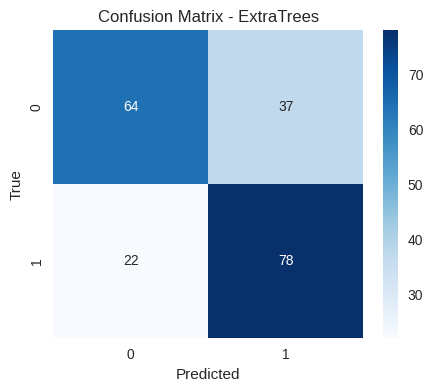

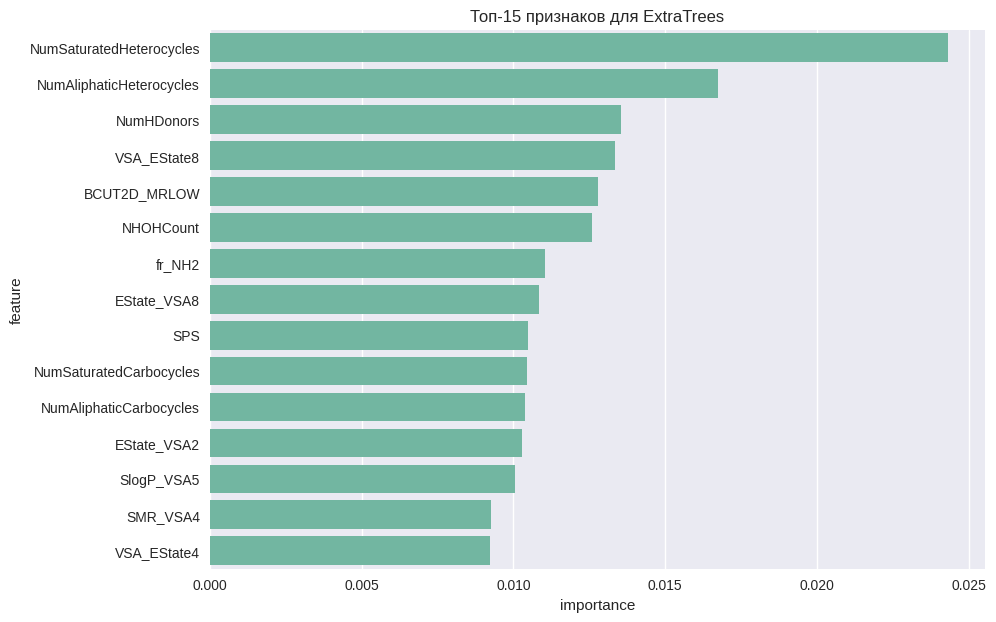

In [12]:
# 9. Визуализация результатов

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

if fi is not None:
    plt.figure(figsize=(10, 7))
    sns.barplot(data=fi.head(15), x="importance", y="feature")
    plt.title(f"Топ-15 признаков для {best_model_name}")
    plt.show()

ИТОГОВЫЕ ВЫВОДЫ ПО CLASSIFICATION: IC50 > MEDIAN
1. Задача:
   - определить, превышает ли IC50 медиану выборки.
2. Были сравнены 4 модели:
   - LogisticRegression
   - RandomForest
   - ExtraTrees
   - GradientBoosting
3. Основной критерий выбора:
   - ROC-AUC
   Дополнительно:
   - F1-score
   - Balanced Accuracy
   - Recall
4. Для задач отбора соединений ROC-AUC важнее обычной Accuracy,
   так как показывает качество ранжирования объектов по вероятности принадлежности к классу.
5. Итоговая модель выбрана по совокупности:
   - 5-fold cross-validation
   - качества на test
   - интерпретируемости признаков